#### Iris flower dataset có sẵn trong thư viện scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

#### Tiếp theo,  ta load dữ liệu và hiện thị vài dữ liệu mẫu. Các class được gán nhãn là 0, 1, và 2

In [2]:
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target

print("Number of classes: %d" % len(np.unique(iris_y)))
print("Number of data points: %d" % len(iris_y))

Number of classes: 3
Number of data points: 150


In [3]:
X0 = iris_X[iris_y == 0,:]
print("\nSamples from class 0:\n", X0[:5,:])

X1 = iris_X[iris_y == 1,:]
print("\nSamples from class 1:\n", X1[:5,:])

X2 = iris_X[iris_y == 2,:]
print("\nSamples from class 2:\n", X2[:5,:])


Samples from class 0:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Samples from class 1:
 [[7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.9 1.5]
 [5.5 2.3 4.  1.3]
 [6.5 2.8 4.6 1.5]]

Samples from class 2:
 [[6.3 3.3 6.  2.5]
 [5.8 2.7 5.1 1.9]
 [7.1 3.  5.9 2.1]
 [6.3 2.9 5.6 1.8]
 [6.5 3.  5.8 2.2]]


#### Nếu nhìn vào vài dữ liệu mẫu, ta thấy rằng hai cột cuối mang khá nhiều thông tin giúp có thể phân biệt được chúng. Ta dự đoán rằng kết quả classification cho cơ sở dữ liệu này sẽ tương đối cao

## Tách training và test sets

#### Giả sử muốn dùng 50 điểm dữ liệu cho test set, 100 điểm còn lại cho training set. Scikit-learn có một hàm số cho phép ta ngẫu nhiên lựa chọn các điểm này:

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size = 50)

print("Training size: %d" % len(y_train))
print("Test size    : %d" % len(y_test))

print(y_test)

Training size: 100
Test size    : 50
[0 2 1 0 2 2 1 0 2 1 0 1 0 0 2 1 1 0 0 2 2 1 1 1 2 2 0 0 2 0 1 0 2 1 0 0 2
 1 0 0 1 1 2 2 1 0 0 1 1 1]


#### Trước hết xét trường hợp đơn giản K = 1, tức là với mỗi điểm test data, ta chỉ xét 1 điểm training data gần nhất và lấy label của điểm đó để dự đoán cho điểm test này

In [5]:
clf = neighbors.KNeighborsClassifier(n_neighbors = 1, p = 2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Print results for 35 test data points:")
print("Predicted labels: ", y_pred[0:35])
print("Ground truth    : ", y_test[0:35])

Print results for 35 test data points:
Predicted labels:  [0 2 2 0 2 2 1 0 2 1 0 1 0 0 2 1 1 0 0 2 2 1 1 1 2 2 0 0 1 0 1 0 2 1 0]
Ground truth    :  [0 2 1 0 2 2 1 0 2 1 0 1 0 0 2 1 1 0 0 2 2 1 1 1 2 2 0 0 2 0 1 0 2 1 0]


#### Kết quả cho thấy label dự đoán gần giống với label thật của test data, có thể có 1 vài điểm trong số 35 điểm được hiển thị có kết quả sai lệch. Ở đây chúng ta làm quen với khái niệm mới: ground truth. Một cách đơn giản, ground truth chính là nhãn/label/đầu ra thực sự của các điểm trong test data. Khái niệm này được dùng nhiều trong Machine Learning

# Phương pháp đánh giá (evaluation method)

#### Để đánh giá độ chính xác của thuật toán KNN classifier này, ta xem xem có bao nhiêu điểm trong test data được dự đoán đúng. Lấy số lượng này chia cho tổng số lượng trong tập test data sẽ ra độ chính xác. Scikit-learn cung cấp hàm số accuracy_score để thực hiện công việc này

In [6]:
from sklearn.metrics import accuracy_score
print("Accuracy of 1NN: %0.2f %%" % (100 * accuracy_score(y_test, y_pred)))

Accuracy of 1NN: 96.00 %


#### 1NN đã cho chúng ta kết quả là khá cao! Chú ý rằng đây là một cơ sở dữ liệu dễ vì chỉ với dữ liệu ở hai cột cuối cùng, ta đã có thể suy ra quy luật. Trong ví dụ này, sử dụng p = 2 nghĩa là khoảng cách ở đây được tính là khoảng cách theo norm 2. Các bạn cũng có thể thử bằng cách thay p = 1 cho norm 1, hoặc các gtri p khác cho norm khác

#### Nhận thấy rằng chỉ xét 1 điểm gần nhất có thể dẫn đến kết quả sai nếu điểm đó là nhiễu. Một cách có thể làm tăng độ chính xác là tăng số lượng điểm lân cận lên, ví dụ 10 điểm, và xem xem trong 10 điểm gần nhất, class nào chiếm đa số thì dự đoán kết quả là class đó. Kỹ thuật dựa vào đa số này được gọi là major voting

In [7]:
clf = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy of 10NN with major voting: %0.2f %%" % (100 * accuracy_score(y_test, y_pred)))

Accuracy of 10NN with major voting: 100.00 %


# Đánh trọng số cho các điểm lân cận

#### Trong kỹ thuật major voting bên trên, mỗi trong 10 điểm gần nhất được coi là có vai trò như nhau và giá trị lá phiếu của mỗi điểm này là như nhau. Như thế là không công bằng, vì rõ ràng rằng những điểm gần hơn nên có trọng số cao hơn (càng thân cận thì càng tin tưởng). Vậy nên sẽ đánh trọng số khác nhau cho mỗi trong 10 điểm gần nhất này. Cách đánh trọng số phải thoải mãn điều kiện là một điểm càng gần điểm test data thì phải được đánh trọng số càng cao(tin tưởng hơn). Cách đơn giản nhất là lấy nghịch đảo của khoảng cách này(Trong trường hợp test data trùng với 1 điểm dữ liệu trong training data, tức khoảng cách bằng 0, ta lấy luôn label của điểm training data)

### Scikit-learn giúp đơn giản hóa việc này bằng cách gán gtri weights = "distance"(Giá trị mặc định của weights là "uniform", tương ứng với việc coi tất cả các điểm lân cận có giá trị như nhau như ở trên)

In [8]:
clf = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2, weights = "distance", algorithm = 'kd_tree')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy of 10NN (1 / distance weights): %0.2f %%" % (100 * accuracy_score(y_test, y_pred)))

Accuracy of 10NN (1 / distance weights): 100.00 %


#### Chú ý: Ngoài 2 phương pháp đánh trọng số weights =  "uniform" và weights = "distance" ở trên, scikit-learn còn cung cấp cho ta một cách để đánh trọng số một cách tùy chọn. Ví dụ, một cách đánh trọng số phổ biến khác trong Machine Learning là:
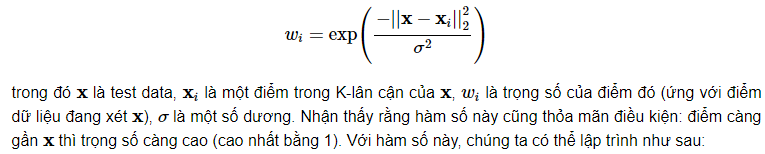

In [12]:
def myWeight(distances):
    sigma2 = 0.5 #We can change this number
    return np.exp(-distances ** 2 / sigma2)

clf = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2, weights = myWeight, algorithm = 'ball_tree')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy of 10NN (customized weights): %0.2f %%" % (100 * accuracy_score(y_test, y_pred)))

Accuracy of 10NN (customized weights): 100.00 %


#### Để đánh giá chính xác hơn kết quả của KNN với K khác nhau, cách định nghĩa khoảng cách khác nhau và cách đánh trọng số khác nhau, ta cần thực hiện quá trình trên với nhiều cách chia dữ liệu training và test khác nhau rồi lấy kết quả trung bình, vì rất có thể dữ liệu phân chia trong 1 trường hợp cụ thể là rất tốt hoặc rất xấu(bias). Đây cũng là cách thường được dùng khi đánh giá hiệu năng của một thuật toán cụ thể

# Test KNN với bộ dữ liệu MNIST

In [10]:
from mnist import MNIST
import time

In [13]:
mndata = MNIST("E:\\LapTrinh\\PYTHON\\AI\\Machine Learning\\K-meansApplication\\MNIST") #Path to your MNIST folder
mndata.load_testing()
mndata.load_training()

X_test = mndata.test_images
X_train = mndata.train_images
y_test = np.asarray(mndata.test_labels)
y_train = np.asarray(mndata.train_labels)

start_time = time.time()

clf = neighbors.KNeighborsClassifier(n_neighbors = 1, p = 2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

end_time = time.time()

print("Accuracy of 1NN for MNIST: %0.2f %%" % (100 * accuracy_score(y_test, y_pred)))
print("Running time: %0.2f (s)" % (end_time - start_time))

Accuracy of 1NN for MNIST: 96.91 %
Running time: 842.24 (s)
